<a href="https://www.kaggle.com/code/kopkritsaikhiao/ds-salaries-for-non-resident-and-predict?scriptVersionId=135365391" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 1. Loading data and importing libraries

In [1]:
%pip install -q pycountry

/private/tmp/claude-501/-Users-tao-Library-Application-Support-Claude-scratch-workspaces-bd3d238e-04e9-48f6-807d-8ba5271bfd8f-3172317b-0dbf-4f75-b499-a55761d2b1c4-scratch-2026-09-30-5a3ea4/c44cd402-9b70-41a0-9ff3-445132d576df/scratchpad/venv312/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pycountry
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import DataLoader, TensorDataset

import torch.nn as nn

# On Kaggle the data lives in /kaggle/input; locally, put the CSV in ./data (see README)
DATA_PATH = '/kaggle/input/data-science-salaries-2023/ds_salaries.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'data/ds_salaries.csv'
print(DATA_PATH)

data/ds_salaries.csv


I know most of all peole here want to get a job in data. so, come to explore it together !!!

In [3]:
# load data and look at the head of df
df = pd.read_csv(DATA_PATH)
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [4]:
# look at the tail of the df
df.tail()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L
3754,2021,SE,FT,Data Science Manager,7000000,INR,94665,IN,50,IN,L


# 2. Change some of the data values to make them easy to understand 

In [5]:
# work_year
df['work_year'] = (df['work_year'] - 2023)*-1
df.tail()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
3750,3,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,3,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,3,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L
3754,2,SE,FT,Data Science Manager,7000000,INR,94665,IN,50,IN,L


In [6]:
df['remote_ratio'] = df['remote_ratio'].apply(lambda x: int(x / 50))
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,2,ES,L
1,0,MI,CT,ML Engineer,30000,USD,30000,US,2,US,S
2,0,MI,CT,ML Engineer,25500,USD,25500,US,2,US,S
3,0,SE,FT,Data Scientist,175000,USD,175000,CA,2,CA,M
4,0,SE,FT,Data Scientist,120000,USD,120000,CA,2,CA,M


In [7]:
# look at experience_level values
unique_levels = df['experience_level'].unique()

print(unique_levels)

['SE' 'MI' 'EN' 'EX']


In [8]:
# Change it
df['experience_level'] = df['experience_level'].replace({'SE': 'Senior', 'MI': 'Mid-level', 'EN': 'Entry', 'EX': 'Executive/Lead'})
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,Senior,FT,Principal Data Scientist,80000,EUR,85847,ES,2,ES,L
1,0,Mid-level,CT,ML Engineer,30000,USD,30000,US,2,US,S
2,0,Mid-level,CT,ML Engineer,25500,USD,25500,US,2,US,S
3,0,Senior,FT,Data Scientist,175000,USD,175000,CA,2,CA,M
4,0,Senior,FT,Data Scientist,120000,USD,120000,CA,2,CA,M


In [9]:
# look at employment_type values
unique_employment_type = df['employment_type'].unique()

print(unique_employment_type)

['FT' 'CT' 'FL' 'PT']


In [10]:
# change it
df['employment_type'] = df['employment_type'].replace({'FT': 'Full-Time', 'CT': 'Contract', 'FL': 'Freelance', 'PT': 'Part-Time'})
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,Senior,Full-Time,Principal Data Scientist,80000,EUR,85847,ES,2,ES,L
1,0,Mid-level,Contract,ML Engineer,30000,USD,30000,US,2,US,S
2,0,Mid-level,Contract,ML Engineer,25500,USD,25500,US,2,US,S
3,0,Senior,Full-Time,Data Scientist,175000,USD,175000,CA,2,CA,M
4,0,Senior,Full-Time,Data Scientist,120000,USD,120000,CA,2,CA,M


In [11]:
# Define function to find country name
def get_country_name(country_code):
    try:
        result = pycountry.countries.get(alpha_2=country_code)
    except Exception:
        return np.nan
    else:
        if result is None:
            return np.nan
        else:
            return result.name

# Given ISO Alpha-2 code, return full country name
df["employee_residence"] = df["employee_residence"].apply(lambda country_code: get_country_name(country_code))
df["company_location"] = df["company_location"].apply(lambda country_code: get_country_name(country_code))
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,Senior,Full-Time,Principal Data Scientist,80000,EUR,85847,Spain,2,Spain,L
1,0,Mid-level,Contract,ML Engineer,30000,USD,30000,United States,2,United States,S
2,0,Mid-level,Contract,ML Engineer,25500,USD,25500,United States,2,United States,S
3,0,Senior,Full-Time,Data Scientist,175000,USD,175000,Canada,2,Canada,M
4,0,Senior,Full-Time,Data Scientist,120000,USD,120000,Canada,2,Canada,M


# 3. Time to explore data

In [12]:
# Use the describe() function to get summary statistics of the DataFrame
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,0.626365,1.906956e+05,137570.389880,0.925433
std,0.691448,6.716765e+05,63055.625278,0.971781
min,0.000000,6.000000e+03,5132.000000,0.000000
25%,0.000000,1.000000e+05,95000.000000,0.000000
50%,1.000000,1.380000e+05,135000.000000,0.000000
75%,1.000000,1.800000e+05,175000.000000,2.000000
max,3.000000,3.040000e+07,450000.000000,2.000000


I find it fascinating because the average salary is around 137,570 USD.

Which is considerably high compared to the average salary in Thailand.

That the reason why I want to chage career path to be a data scientist.

In [13]:
# print all unique value
def summary(df):
    print(f"Dataset has {df.shape[1]} features and {df.shape[0]} examples.")
    print(f"Duplicated rows: {df.duplicated().sum()}")
    summary = pd.DataFrame(index=df.columns)
    summary["Unique"] = df.nunique().values
    summary["Missing"] = df.isnull().sum().values
    summary["Types"] = df.dtypes
    return summary

summary(df)

Dataset has 11 features and 3755 examples.
Duplicated rows: 1171


,Unique,Missing,Types
work_year,4,0,int64
experience_level,4,0,object
employment_type,4,0,object
job_title,93,0,object
salary,815,0,int64
salary_currency,20,0,object
salary_in_usd,1035,0,int64
employee_residence,78,0,object
remote_ratio,3,0,int64
company_location,72,0,object


we can see there are a lot of values in job_title.

There are also 1,171 fully duplicated rows. They might be different people with the same job, country and salary, so we keep them for the EDA. We remove them before modelling (section 5) so the same row cannot end up in both the train and test sets.

In [14]:
unique_job_title = df['job_title'].unique()

# Create a DataFrame with the unique job titles
df_job_titles = pd.DataFrame({'job_title': unique_job_title})

# Group the job titles by common themes
grouped_job_titles = df_job_titles.groupby(df_job_titles['job_title'].str.split().str[0]).agg({'job_title': ', '.join})

# Print the grouped job titles
print("Grouped Job Titles:")
for group, titles in grouped_job_titles.iterrows():
    print("- " + group + ":")
    print("  " + titles['job_title'])
    print()


Grouped Job Titles:
- 3D:
  3D Computer Vision Researcher

- AI:
  AI Developer, AI Scientist, AI Programmer

- Analytics:
  Analytics Engineer

- Applied:
  Applied Scientist, Applied Machine Learning Engineer, Applied Data Scientist, Applied Machine Learning Scientist

- Autonomous:
  Autonomous Vehicle Technician

- Azure:
  Azure Data Engineer

- BI:
  BI Data Engineer, BI Developer, BI Analyst, BI Data Analyst

- Big:
  Big Data Engineer, Big Data Architect

- Business:
  Business Intelligence Engineer, Business Data Analyst

- Cloud:
  Cloud Database Engineer, Cloud Data Engineer, Cloud Data Architect

- Compliance:
  Compliance Data Analyst

- Computer:
  Computer Vision Engineer, Computer Vision Software Engineer

- Data:
  Data Scientist, Data Analyst, Data Modeler, Data Strategist, Data Engineer, Data Quality Analyst, Data Architect, Data Analytics Manager, Data DevOps Engineer, Data Science Manager, Data Manager, Data Specialist, Data Infrastructure Engineer, Data Operations

In [15]:
# Count the number of job titles in each group
count_per_group = df['job_title'].value_counts()

# Print the grouped job titles with count
print("Grouped Job Titles:")
for group, count in count_per_group.items():
    print(f"- {group}: {count}")

Grouped Job Titles:
- Data Engineer: 1040
- Data Scientist: 840
- Data Analyst: 612
- Machine Learning Engineer: 289
- Analytics Engineer: 103
- Data Architect: 101
- Research Scientist: 82
- Data Science Manager: 58
- Applied Scientist: 58
- Research Engineer: 37
- ML Engineer: 34
- Data Manager: 29
- Machine Learning Scientist: 26
- Data Science Consultant: 24
- Data Analytics Manager: 22
- Computer Vision Engineer: 18
- AI Scientist: 16
- BI Data Analyst: 15
- Business Data Analyst: 15
- Data Specialist: 14
- BI Developer: 13
- Applied Machine Learning Scientist: 12
- Machine Learning Infrastructure Engineer: 11
- Big Data Engineer: 11
- Director of Data Science: 11
- AI Developer: 11
- Applied Data Scientist: 10
- Head of Data: 10
- Machine Learning Software Engineer: 10
- Data Operations Engineer: 10
- ETL Developer: 10
- BI Analyst: 9
- Head of Data Science: 9
- Lead Data Scientist: 9
- Data Science Lead: 8
- Principal Data Scientist: 8
- Data Quality Analyst: 7
- NLP Engineer: 7

so, you can see that the most top 3 hired job are:

- Data Engineer: 1040
- Data Scientist: 840
- Data Analyst: 612

In [16]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [17]:
selected_columns = ['work_year', 'experience_level', 'employment_type', 
                    'salary_currency', 'salary_in_usd', 'employee_residence',
                    'remote_ratio', 'company_location', 'company_size']

import plotly.express as px

def plot_distributions(df):
    for column in selected_columns:
        fig = px.histogram(df, x=column, nbins=30, title=f"Distribution of {column}")
        fig.update_layout(
            xaxis_title=column,
            yaxis_title="Frequency",
            xaxis={'tickangle': -45},
            showlegend=False
        )
        fig.show()

plot_distributions(df)

from the plots above we can see the distribution of each feature.

In [18]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [19]:
fig = px.box(df, x='experience_level', y='salary_in_usd', color='experience_level')
fig.show()

In [20]:
fig = px.box(df, x='employee_residence', y='salary_in_usd', color='experience_level')
fig.show()

In [21]:
fig = px.box(df, x='company_location', y='salary_in_usd', color='experience_level')
fig.show()

# 4.  explore data about Non-residence

I living in Thailand. However, I want to work in a difference country.
So, I want to explore about that.

In [22]:
# create data for non resident
count_non_residence = df[df['employee_residence'] != df['company_location']]
count_non_residence.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
81,0,Senior,Full-Time,Machine Learning Engineer,150000,USD,150000,Portugal,2,United States,M
82,0,Mid-level,Full-Time,Applied Machine Learning Engineer,65000,EUR,69751,India,2,Germany,S
183,3,Executive/Lead,Full-Time,Staff Data Analyst,15000,USD,15000,Nigeria,0,Canada,M
218,0,Senior,Full-Time,Applied Data Scientist,100000,AUD,68318,Australia,2,Finland,M
249,1,Senior,Full-Time,Data Scientist,84000,EUR,88256,Spain,2,United Kingdom,L


In [23]:
count_non_residence = len(df[df['employee_residence'] != df['company_location']])
count_residence = len(df[df['employee_residence'] == df['company_location']])

labels = ['Non-Resident', 'Resident']
values = [count_non_residence, count_residence]

fig = px.pie(names=labels, values=values)
fig.show()

There are 96 people whose country of residence is different from their company's country.

This accounts for approximately 2.56% of the records in the dataset.

In [24]:
# Create two dataframes for resident and non-resident employees
resident_employees = df[df['employee_residence'] == df['company_location']]
non_resident_employees = df[df['employee_residence'] != df['company_location']]

selected_columns = ['work_year', 'experience_level', 'employment_type', 
                    'salary_currency', 'salary_in_usd', 'employee_residence',
                    'remote_ratio', 'company_location', 'company_size']

def plot_distributionsread_red(df):
    for column in selected_columns:
        fig = px.histogram(df, x=column, nbins=30, title=f"Distribution of {column}")
        fig.update_layout(
            xaxis_title=column,
            yaxis_title="Frequency",
            xaxis={'tickangle': -45},
            showlegend=False
        )
        
        # Change histogram color to red
        fig.update_traces(marker=dict(color='red'))
        
        fig.show()

plot_distributionsread_red(non_resident_employees)


Based on the updated information, it appears that India has the highest number of non-residence hires. 

These hires are compensated in United States dollars (USD), 

and most of them work remotely. 

However, it is worth noting that Thailand is not mentioned as one of the countries with a significant number of non-residence hires.

In [25]:
# Create two dataframes for resident and non-resident employees
resident_employees = df[df['employee_residence'] == df['company_location']]
non_resident_employees = df[df['employee_residence'] != df['company_location']]

# Get the salary values for resident and non-resident employees
resident_salaries = resident_employees['salary_in_usd']
non_resident_salaries = non_resident_employees['salary_in_usd']

# Create the boxplot trace for resident employees
trace_resident = go.Box(
    y=resident_salaries,
    name='Resident Employees'
)

# Create the boxplot trace for non-resident employees
trace_non_resident = go.Box(
    y=non_resident_salaries,
    name='Non-Resident Employees'
)

# Create the data list for the boxplot
data = [trace_resident, trace_non_resident]

# Create the layout for the plot
layout = go.Layout(
    title='Salary in USD for Resident and Non-Resident Employees',
    xaxis=dict(title='Employee Type'),
    yaxis=dict(title='Salary in USD')
)

# Create the figure object
fig = go.Figure(data=data, layout=layout)

# Display the plot
fig.show()


The box plot shows salaries, not head counts: the median salary is about 135,000 USD for residents and about 55,000 USD for non-residents.

So in this dataset, working for a company in another country usually means a *lower* salary. Most non-residents work remotely from lower-cost countries (India is the largest group) for companies abroad. Moving to the company's country and being hired as a resident is what comes with the higher salaries.

That is still useful for me: a remote job abroad would probably pay less than a local job in the US, but it can still be well above typical salaries in Thailand.

# 5. Encoding categorical features


Models need numbers, so the text columns have to be converted. How we convert them matters:

* **Ordinal** features have a natural order, so a single number is fine: experience level (Entry < Mid-level < Senior < Executive) and company size (S < M < L).
* **Nominal** features have no order: job title, country, employment type. Using `LabelEncoder` here would tell the model that job title 84 is "bigger" than job title 66, which is meaningless. One-hot encoding avoids this by giving each category its own 0/1 column.

First we remove the exact duplicate rows.


In [26]:

df_model = df.drop_duplicates().reset_index(drop=True)
print(f"{len(df)} rows -> {len(df_model)} rows after removing duplicates")

experience_order = ['Entry', 'Mid-level', 'Senior', 'Executive/Lead']
size_order = ['S', 'M', 'L']


3755 rows -> 2584 rows after removing duplicates


# 6. K-means


K-means groups points by distance, so every feature must be on a similar scale. Otherwise the feature with the biggest numbers (salary) decides everything.

We cluster on a small set of features that describe the job, all scaled with `StandardScaler`:

* salary (log scale, so a few very high salaries do not dominate)
* experience level and company size (ordinal)
* remote ratio and years before 2023
* whether the job is full-time and whether the company is in the US

We use `salary_in_usd` only, not `salary` in local currency. Using both would count salary twice, and the local-currency numbers can't be compared across countries.


In [27]:

from sklearn.preprocessing import StandardScaler

X_cluster = pd.DataFrame({
    'log_salary_usd': np.log(df_model['salary_in_usd']),
    'experience': df_model['experience_level'].map({v: i for i, v in enumerate(experience_order)}),
    'company_size': df_model['company_size'].map({v: i for i, v in enumerate(size_order)}),
    'remote_ratio': df_model['remote_ratio'],
    'years_before_2023': df_model['work_year'],
    'full_time': (df_model['employment_type'] == 'Full-Time').astype(int),
    'us_company': (df_model['company_location'] == 'United States').astype(int),
})
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)
X_cluster.head()


,log_salary_usd,experience,company_size,remote_ratio,years_before_2023,full_time,us_company
0,11.360322,2,2,2,0,1,0
1,10.308953,1,0,2,0,0,1
2,10.146434,1,0,2,0,0,1
3,12.072541,2,1,2,0,1,0
4,11.695247,2,1,2,0,1,0


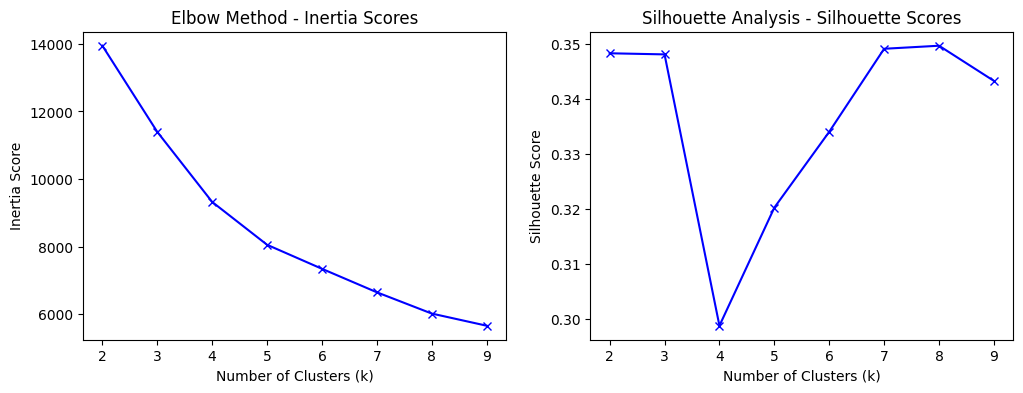

k with the highest silhouette score: 8


In [28]:

# Define the range of k values to evaluate
k_values = range(2, 10)

# Initialize lists to store the inertia and silhouette scores
inertia_scores = []
silhouette_scores = []

# Iterate over different k values
for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_cluster_scaled)
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, inertia_scores, 'bx-')
axes[0].set(xlabel='Number of Clusters (k)', ylabel='Inertia Score', title='Elbow Method - Inertia Scores')
axes[1].plot(k_values, silhouette_scores, 'bx-')
axes[1].set(xlabel='Number of Clusters (k)', ylabel='Silhouette Score', title='Silhouette Analysis - Silhouette Scores')
plt.show()

best_k = list(k_values)[int(np.argmax(silhouette_scores))]
print("k with the highest silhouette score:", best_k)


The silhouette scores are all between 0.30 and 0.35, so the data has no strong natural number of groups. We use the k with the highest score (k = 8), and the clusters turn out to be easy to describe.

In the first version of this notebook, k-means produced one cluster of 3,746 rows and one of 9. That wasn't really class imbalance. The features were not scaled, so `salary` in local currency (up to 30 million) dominated the distances, and the 9 rows were simply the largest local-currency salaries. With scaled features, the clusters below are much more balanced.

In [29]:

# Determine the number of clusters (k)
k = best_k

kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
df_model['cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Count the number of data points in each cluster
df_model['cluster'].value_counts().sort_index()


cluster
0    732
1    269
2    691
3    197
4    166
5    319
6    173
7     37
Name: count, dtype: int64

Now we describe each cluster using the original, readable columns.

In [30]:

cluster_profile = df_model.groupby('cluster').agg(
    size=('salary_in_usd', 'size'),
    median_salary_usd=('salary_in_usd', 'median'),
    most_common_level=('experience_level', lambda s: s.mode()[0]),
    share_senior_or_exec=('experience_level', lambda s: s.isin(['Senior', 'Executive/Lead']).mean()),
    share_fully_remote=('remote_ratio', lambda s: (s == 2).mean()),
    share_us_company=('company_location', lambda s: (s == 'United States').mean()),
    share_full_time=('employment_type', lambda s: (s == 'Full-Time').mean()),
).round(2)
cluster_profile


,size,median_salary_usd,most_common_level,share_senior_or_exec,share_fully_remote,share_us_company,share_full_time
cluster,,,,,,,
0,732,150000.0,Senior,0.84,1.00,1.00,1.0
1,269,121500.0,Mid-level,0.00,0.09,1.00,1.0
2,691,154560.0,Senior,1.00,0.00,1.00,1.0
3,197,145000.0,Senior,0.57,0.65,0.95,1.0
4,166,45828.0,Entry,0.14,0.60,0.17,1.0
5,319,84053.0,Mid-level,0.49,0.42,0.00,1.0
6,173,54094.0,Mid-level,0.24,0.43,0.02,1.0
7,37,34320.0,Entry,0.16,0.62,0.49,0.0


In [31]:

fig = px.box(df_model, x='cluster', y='salary_in_usd', color='experience_level',
             category_orders={'experience_level': experience_order},
             title='Salary by cluster and experience level')
fig.show()


Reading the table above, the clusters are:

| cluster | who | median salary |
|---|---|---|
| 2 | US companies, senior, on-site | ~155k |
| 0 | US companies, senior, fully remote | ~150k |
| 3 | US, large companies, older records (2020-21) | ~145k |
| 1 | US companies, entry / mid-level, on-site | ~122k |
| 5 | outside the US (mostly UK, Canada), mid / senior | ~84k |
| 6 | outside the US (India, UK), large companies, older records | ~54k |
| 4 | small companies, mostly outside the US, entry-level | ~46k |
| 7 | not full-time (contract, freelance, part-time) | ~34k |

The biggest split is **whether the company is in the US**, then experience level. Senior people at US companies earn almost the same whether they are remote or on-site (150k vs 155k). For someone outside the US, a remote job at a US company is therefore the interesting option.

# 7. Predict salary


## select features and target
We leave out `salary` and `salary_currency`, because they already contain the answer. We also leave out `employee_residence`, since it is almost the same as `company_location`.

The target is `log(salary_in_usd)`. Salaries are right-skewed, and on a log scale a 10% error counts the same for a 50k and a 200k salary. We convert predictions back to USD when we measure errors.


In [32]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

features = ['work_year', 'experience_level', 'employment_type',
            'job_title', 'remote_ratio', 'company_location', 'company_size']

X = df_model[features]
y = np.log(df_model['salary_in_usd'].values)

# Rare job titles / countries (fewer than 10 rows) are grouped into one 'infrequent' column
preprocess = make_pipeline(
    ColumnTransformer([
        ('ordinal', OrdinalEncoder(categories=[experience_order, size_order]), ['experience_level', 'company_size']),
        ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=10, sparse_output=False),
         ['employment_type', 'job_title', 'company_location']),
        ('numeric', 'passthrough', ['work_year', 'remote_ratio']),
    ]),
    StandardScaler(),
)



## split train, validation and test
* **train**: fits the models
* **validation**: tells the neural network when to stop training (early stopping)
* **test**: used only once at the end to measure every model fairly

The encoders and scaler are fitted on the training set only, so no information from the test set leaks in.


In [33]:

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.15, random_state=42)

X_train_enc = preprocess.fit_transform(X_train)
X_val_enc = preprocess.transform(X_val)
X_test_enc = preprocess.transform(X_test)

print("Train / validation / test rows:", len(X_train), len(X_val), len(X_test))
print("Number of encoded features:", X_train_enc.shape[1])


Train / validation / test rows: 1756 311 517
Number of encoded features: 39



## baseline and metrics
To know if a model is any good, we compare it with a baseline that ignores all features and always predicts the median training salary. We report:

* **MAE**: average error in USD
* **RMSE**: like MAE, but punishes big errors more
* **R²**: share of the salary variation the model explains (0 = no better than a constant, 1 = perfect)


In [34]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = {}
y_test_usd = np.exp(y_test)

def evaluate(pred_log):
    pred_usd = np.exp(pred_log)
    return {
        'MAE (USD)': mean_absolute_error(y_test_usd, pred_usd),
        'RMSE (USD)': mean_squared_error(y_test_usd, pred_usd) ** 0.5,
        'R2': r2_score(y_test_usd, pred_usd),
    }

results['Baseline (median salary)'] = evaluate(np.full(len(y_test), np.median(y_train)))
results['Baseline (median salary)']


{'MAE (USD)': 53555.26499032882,
 'RMSE (USD)': 66194.55786755029,
 'R2': -0.0017483961569213502}

## simple models for comparison

In [35]:

from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor

ridge = Ridge(alpha=1.0).fit(X_train_enc, y_train)
results['Ridge regression'] = evaluate(ridge.predict(X_test_enc))

gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
gbr.fit(X_train_enc, y_train)
results['Gradient boosting'] = evaluate(gbr.predict(X_test_enc))

pd.DataFrame(results).T.round(3)


,MAE (USD),RMSE (USD),R2
Baseline (median salary),53555.265,66194.558,-0.002
Ridge regression,38242.021,52230.905,0.376
Gradient boosting,38847.662,52498.153,0.370



## PyTorch model
The network needs the target on a small scale too. We standardize the log salary (mean 0, standard deviation 1) and undo this after predicting.


In [36]:

torch.manual_seed(42)

y_mean, y_std = y_train.mean(), y_train.std()

def to_tensors(X_enc, y_log):
    return (torch.tensor(X_enc, dtype=torch.float32),
            torch.tensor((y_log - y_mean) / y_std, dtype=torch.float32).unsqueeze(1))

X_train_t, y_train_t = to_tensors(X_train_enc, y_train)
X_val_t, y_val_t = to_tensors(X_val_enc, y_val)
X_test_t, _ = to_tensors(X_test_enc, y_test)

batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
print("Number of batches in training loader: ", len(train_loader))


Number of batches in training loader:  55


## Create Model

In [37]:

class Model(nn.Module):
    def __init__(self, n_features):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(n_features, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

model = Model(X_train_t.shape[1])
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters()))


Model(
  (fc1): Linear(in_features=39, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=128, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=128, out_features=1, bias=True)
)
Trainable parameters: 11009



## Train model
We train for at most 500 epochs. After each epoch we check the loss on the validation set and keep the best weights. If validation loss has not improved for 30 epochs we stop, because the model has started to memorize the training data (overfitting).


In [38]:

import copy
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

max_epochs, patience = 500, 30
train_loss, val_loss = [], []
best_val, best_state, epochs_without_improvement = float('inf'), None, 0

for epoch in range(max_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(inputs), targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    train_loss.append(running_loss / len(X_train_t))

    model.eval()
    with torch.no_grad():
        val_loss.append(criterion(model(X_val_t), y_val_t).item())

    if val_loss[-1] < best_val:
        best_val, best_state, epochs_without_improvement = val_loss[-1], copy.deepcopy(model.state_dict()), 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            break

model.load_state_dict(best_state)
best_epoch = int(np.argmin(val_loss)) + 1
print(f"Stopped after {epoch + 1} epochs; best validation loss {best_val:.4f} at epoch {best_epoch}")


Stopped after 41 epochs; best validation loss 0.4916 at epoch 11


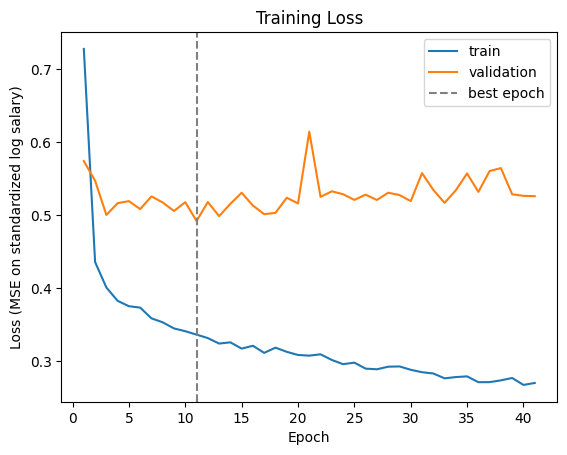

In [39]:

# Plot the training and validation loss
plt.plot(range(1, len(train_loss) + 1), train_loss, label='train')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='validation')
plt.axvline(best_epoch, color='gray', linestyle='--', label='best epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE on standardized log salary)')
plt.title('Training Loss')
plt.legend()
plt.show()


## Save model

In [40]:
torch.save(model.state_dict(), 'model.pth')

## Eval model

In [41]:

model.eval()
with torch.no_grad():
    nn_pred_log = model(X_test_t).numpy().ravel() * y_std + y_mean

results['PyTorch MLP'] = evaluate(nn_pred_log)

comparison = pd.DataFrame(results).T
comparison.style.format({'MAE (USD)': '{:,.0f}', 'RMSE (USD)': '{:,.0f}', 'R2': '{:.3f}'})


,MAE (USD),RMSE (USD),R2
Baseline (median salary),"53,555","66,195",-0.002
Ridge regression,"38,242","52,231",0.376
Gradient boosting,"38,848","52,498",0.370
PyTorch MLP,"38,972","53,664",0.342


In [42]:

fig = px.scatter(x=y_test_usd, y=np.exp(nn_pred_log), opacity=0.5,
                 labels={'x': 'Actual salary (USD)', 'y': 'Predicted salary (USD)'},
                 title='PyTorch model: predicted vs actual salary on the test set')
fig.add_shape(type='line', x0=0, y0=0, x1=y_test_usd.max(), y1=y_test_usd.max(), line=dict(dash='dash'))
fig.show()


### results

* The baseline (always predict the median) is off by about **53,600 USD** on average (MAE), with R² ≈ 0.
* The PyTorch model is off by about **39,000 USD** on average and explains about 34% of the salary variation (R² 0.34). That is a real improvement over the baseline.
* Ridge regression and gradient boosting do the same or slightly better (MAE ~38,000, R² ~0.37) and train in under a second. The dataset is small (about 1,750 training rows) and almost every feature is categorical, so a neural network has no advantage here.
* R² stays below 0.4 because a lot of what decides a salary isn't in the data: the specific company, city, skills, and negotiation.

For comparison, the first version of this notebook had a test MSE of 2.89e9. That is an RMSE of about 53,800 USD, roughly what the baseline gets. Scaling the inputs and target, one-hot encoding, and early stopping made the difference, and training now takes seconds instead of 29 minutes.

# Thank you for attention 

Thank you for taking the time to read and engage with this information! If you found it helpful or enjoyable, please consider giving it an upvote. Positive feedback like this greatly motivates me to continue exploring new areas and sharing my knowledge.

This notebook provided me with many ideas for exploring data. I got inspiration from the techniques and insights shared in this Kaggle notebook:
https://www.kaggle.com/code/arnabchaki/eda-on-data-science-salaries/notebook